# P6e: WFA CAGR 4.57% の原因診断

`src/backtest_wfa.py` の 2024-01-01〜2026-09-02 検証について、
CAGR 15% 目標に届かなかった要因を、保存済みP6d成果物と読み取り専用SQLiteから再検証する。
これは診断用ノートブックであり、本番DBや外部サービスを更新しない。

## tl;dr

次のセルで、再計算した数値から結論を自動生成する。

## Context & Methods

- 評価単位: 日次ポートフォリオ資産（3つの非重複OOS区間を連結）
- 対象期間: シグナル計算開始 2024-01-01、OOS 2024-08-28〜2026-09-02
- 基準条件: 元本300万円、最大20銘柄、100株単元、手数料10bps、スリッページ5bps
- 反実仮想: P6dで各foldに選ばれたシグナル・パラメータを固定し、執行条件だけを変更
- 因果表現: 反実仮想はモデル内の感度であり、実運用の収益因果や将来成績を保証しない
- データ品質: 明示的な調整係数で株式数基準を統一し、基準不明銘柄は既存実装どおり除外

In [1]:
from __future__ import annotations

import gc
import json
import os
from dataclasses import asdict
from pathlib import Path

from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.backtest_wfa import (
    DEFAULT_PARAM_GRID,
    ExecutionConfig,
    PortfolioSimulator,
    StrategyParams,
    _optimization_score,
    build_walk_forward_folds,
    combine_oos_equity,
    load_price_history,
    prepare_price_history,
    summarize_portfolio,
)

PROJECT_ROOT = Path.cwd()
DB_PATH = PROJECT_ROOT / "stock_data.db"
P6D_DIR = Path(os.environ.get("P6D_WFA_DIR", PROJECT_ROOT / "reports" / "wfa"))
START_DATE = "2024-01-01"
END_DATE = "2026-09-02"
TARGET_CAGR = 0.15

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "baseline": "#0072B2",
    "lot1": "#E69F00",
    "zero_cost": "#009E73",
    "negative": "#D55E00",
}

## Data

一次データはローカルの `stock_data.db`（読み取り専用接続）と、P6d実行時に保存した
`wfa_summary.json` / `wfa_folds.csv` / `wfa_equity.csv` / `wfa_trades.csv`。
計算ロジックはリポジトリの `src/backtest_wfa.py` を直接使う。

In [2]:
required_artifacts = [
    P6D_DIR / "wfa_summary.json",
    P6D_DIR / "wfa_folds.csv",
    P6D_DIR / "wfa_equity.csv",
    P6D_DIR / "wfa_trades.csv",
]
missing = [str(path) for path in [DB_PATH, *required_artifacts] if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Required inputs are missing: {missing}")

artifact_summary = json.loads(required_artifacts[0].read_text(encoding="utf-8"))
artifact_folds = pd.read_csv(required_artifacts[1])
artifact_equity = pd.read_csv(required_artifacts[2], parse_dates=["date"])
artifact_trades = pd.read_csv(
    required_artifacts[3],
    parse_dates=["signal_date", "entry_date", "exit_date"],
)

prices = load_price_history(
    DB_PATH,
    start_date=START_DATE,
    end_date=END_DATE,
)
prepared, data_quality = prepare_price_history(prices)

data_receipt = pd.DataFrame(
    [
        {
            "source": "stock_data.db + src/backtest_wfa.py",
            "rows": data_quality["input_rows"],
            "codes": data_quality["input_codes"],
            "eligible_rows": data_quality["eligible_rows"],
            "eligible_codes": data_quality["eligible_codes"],
            "excluded_codes": data_quality["excluded_codes"],
        },
        {
            "source": "P6d OOS artifacts",
            "rows": len(artifact_equity),
            "codes": artifact_trades["code"].astype(str).nunique(),
            "eligible_rows": len(artifact_trades),
            "eligible_codes": np.nan,
            "excluded_codes": np.nan,
        },
    ]
)
display(data_receipt)

,source,rows,codes,eligible_rows,eligible_codes,excluded_codes
0,stock_data.db + src/backtest_wfa.py,1416163,1571,1320842,1463.0,108.0
1,P6d OOS artifacts,478,160,230,NaN,NaN


In [3]:
def params_from_fold(row: pd.Series) -> StrategyParams:
    return StrategyParams(
        dip_threshold=float(row["param_dip_threshold"]),
        stop_loss=float(row["param_stop_loss"]),
        trailing_stop=float(row["param_trailing_stop"]),
        market_threshold=float(row["param_market_threshold"]),
    )


def run_fixed_selected_params(execution: ExecutionConfig):
    """Re-run OOS folds while holding the P6d-selected strategy parameters fixed."""
    simulator = PortfolioSimulator(prepared, execution)
    curves: list[pd.DataFrame] = []
    trades: list[pd.DataFrame] = []
    exposure_rows: list[dict[str, float | int]] = []
    for _, row in artifact_folds.sort_values("fold").iterrows():
        fold = int(row["fold"])
        params = params_from_fold(row)
        equity, fold_trades = simulator.run(
            params,
            start_date=row["test_start"],
            end_date=row["test_end"],
        )
        equity = equity.copy()
        equity["fold"] = fold
        fold_trades = fold_trades.copy()
        fold_trades["fold"] = fold
        curves.append(equity)
        trades.append(fold_trades)
        exposure_rows.append(
            {
                "fold": fold,
                "average_cash_ratio": float((equity["cash"] / equity["equity"]).mean()),
                "average_positions": float(equity["positions"].mean()),
                "days_at_max_positions": int((equity["positions"] == execution.max_positions).sum()),
                "trading_days": int(len(equity)),
            }
        )
    combined_equity = combine_oos_equity(curves, execution.initial_capital)
    combined_trades = pd.concat(trades, ignore_index=True)
    summary = summarize_portfolio(
        combined_equity,
        combined_trades,
        initial_capital=execution.initial_capital,
    )
    return summary, combined_equity, combined_trades, pd.DataFrame(exposure_rows), simulator


baseline_execution = ExecutionConfig()
baseline_fixed = run_fixed_selected_params(baseline_execution)
baseline_fixed_summary, baseline_fixed_equity, baseline_fixed_trades, exposure, baseline_simulator = baseline_fixed

if not np.isclose(
    baseline_fixed_summary["final_equity"],
    artifact_summary["final_equity"],
    rtol=0,
    atol=0.01,
):
    raise AssertionError("P6d artifact could not be reproduced within one yen")

display(
    pd.DataFrame(
        [
            {
                "check": "P6d final equity reproduction",
                "artifact": artifact_summary["final_equity"],
                "recomputed": baseline_fixed_summary["final_equity"],
                "absolute_difference": abs(
                    artifact_summary["final_equity"] - baseline_fixed_summary["final_equity"]
                ),
            }
        ]
    )
)

,check,artifact,recomputed,absolute_difference
0,P6d final equity reproduction,3.282575e+06,3.282575e+06,0.0


## Results

### 1. OOS成績と取引損益の分解

In [4]:
slippage_rate = baseline_execution.slippage_bps / 10_000
trade_costs = artifact_trades.copy()
trade_costs["entry_raw_price"] = trade_costs["entry_fill"] / (1 + slippage_rate)
trade_costs["exit_raw_price"] = trade_costs["exit_fill"] / (1 - slippage_rate)
trade_costs["slippage_cost"] = trade_costs["qty"] * (
    (trade_costs["entry_fill"] - trade_costs["entry_raw_price"])
    + (trade_costs["exit_raw_price"] - trade_costs["exit_fill"])
)
trade_costs["fee_cost"] = trade_costs["entry_fee"] + trade_costs["exit_fee"]
trade_costs["gross_pnl_before_cost"] = (
    trade_costs["net_pnl"] + trade_costs["slippage_cost"] + trade_costs["fee_cost"]
)

cost_summary = pd.DataFrame(
    [
        {
            "net_trade_pnl_independent_folds": trade_costs["net_pnl"].sum(),
            "fees": trade_costs["fee_cost"].sum(),
            "slippage": trade_costs["slippage_cost"].sum(),
            "total_cost": (trade_costs["fee_cost"] + trade_costs["slippage_cost"]).sum(),
            "gross_pnl_before_cost": trade_costs["gross_pnl_before_cost"].sum(),
        }
    ]
)

exit_summary = (
    trade_costs.groupby("reason", as_index=False)
    .agg(
        trades=("code", "size"),
        net_pnl=("net_pnl", "sum"),
        mean_net_return=("net_return", "mean"),
        win_rate=("net_return", lambda values: (values > 0).mean()),
    )
    .sort_values("net_pnl", ascending=False)
)
display(cost_summary.style.format("{:,.2f}"))
display(exit_summary.style.format({"net_pnl": "{:,.0f}", "mean_net_return": "{:.2%}", "win_rate": "{:.1%}"}))

,net_trade_pnl_independent_folds,fees,slippage,total_cost,gross_pnl_before_cost
0,"320,028.76","56,926.24","28,463.22","85,389.46","405,418.22"


,reason,trades,net_pnl,mean_net_return,win_rate
0,EndOfFold,41,"693,785",13.27%,78.0%
2,GapStop,34,"82,779",2.94%,32.4%
1,EntryDayStop,1,"-15,155",-10.22%,0.0%
3,StopOrTrail,154,"-441,379",-2.05%,26.0%


独立fold損益は各foldを300万円から再開する会計値であり、OOS資産曲線の連結後最終資産とは
直接一致しない。ここでは取引コストの比率を見るためだけに使う。

In [5]:
fold_performance = artifact_folds[
    [
        "fold",
        "test_start",
        "test_end",
        "test_total_return",
        "test_max_drawdown",
        "test_trades",
    ]
].merge(exposure, on="fold", how="left")
display(
    fold_performance.style.format(
        {
            "test_total_return": "{:.2%}",
            "test_max_drawdown": "{:.2%}",
            "average_cash_ratio": "{:.1%}",
            "average_positions": "{:.1f}",
        }
    )
)

,fold,test_start,test_end,test_total_return,test_max_drawdown,test_trades,average_cash_ratio,average_positions,days_at_max_positions,trading_days
0,1,2024-08-28,2025-04-24,-10.20%,-10.71%,108,44.9%,13.5,0,160
1,2,2025-04-25,2025-12-17,7.14%,-6.45%,52,29.4%,17.3,65,159
2,3,2025-12-18,2026-09-02,13.73%,-8.13%,70,38.1%,14.4,19,159


### 2. 100株単元と150,000円/枠の感度

`lot_size=1` はパラメータを再選択せず、同じシグナルと同じfoldパラメータで執行単位だけを変える。
現行の100株売買ルールに対する診断用上限であり、実運用可能性を意味しない。

In [6]:
lot1_execution = ExecutionConfig(lot_size=1)
lot1_summary, lot1_equity, lot1_trades, _, lot1_simulator = run_fixed_selected_params(lot1_execution)
del lot1_simulator
gc.collect()

zero_cost_execution = ExecutionConfig(commission_bps=0.0, slippage_bps=0.0)
zero_cost_summary, zero_cost_equity, zero_cost_trades, _, zero_cost_simulator = run_fixed_selected_params(zero_cost_execution)
del zero_cost_simulator
gc.collect()

scenario_rows = []
for scenario, summary in [
    ("baseline_100_shares", baseline_fixed_summary),
    ("fixed_params_1_share_diagnostic", lot1_summary),
    ("fixed_params_zero_cost", zero_cost_summary),
]:
    scenario_rows.append(
        {
            "scenario": scenario,
            "final_equity": summary["final_equity"],
            "total_return": summary["total_return"],
            "cagr": summary["cagr"],
            "max_drawdown": summary["max_drawdown"],
            "trades": summary["trades"],
            "average_positions": summary["average_positions"],
        }
    )
scenario_comparison = pd.DataFrame(scenario_rows)
display(
    scenario_comparison.style.format(
        {
            "final_equity": "{:,.0f}",
            "total_return": "{:.2%}",
            "cagr": "{:.2%}",
            "max_drawdown": "{:.2%}",
            "average_positions": "{:.1f}",
        }
    )
)

,scenario,final_equity,total_return,cagr,max_drawdown,trades,average_positions
0,baseline_100_shares,"3,282,575",9.42%,4.57%,-10.71%,230,15.1
1,fixed_params_1_share_diagnostic,"3,776,647",25.89%,12.12%,-22.14%,357,18.2
2,fixed_params_zero_cost,"3,431,660",14.39%,6.91%,-9.57%,226,15.2


In [7]:
target_budget = baseline_execution.initial_capital / baseline_execution.max_positions
date_index = {date: index for index, date in enumerate(baseline_simulator.trading_dates)}
candidate_lot_rows: list[dict[str, object]] = []
for _, fold_row in artifact_folds.sort_values("fold").iterrows():
    fold = int(fold_row["fold"])
    params = params_from_fold(fold_row)
    cache = baseline_simulator._candidate_codes_by_date(params)
    test_dates = [
        date
        for date in baseline_simulator.trading_dates
        if pd.Timestamp(fold_row["test_start"]) <= date <= pd.Timestamp(fold_row["test_end"])
    ]
    for current_date in test_dates[:-1]:
        current_index = date_index[current_date]
        if current_index == 0:
            continue
        previous_date = baseline_simulator.trading_dates[current_index - 1]
        daily = baseline_simulator.rows_by_date[current_date]
        for code in cache.get(previous_date, ()):
            if code not in daily.index:
                continue
            raw_open = float(daily.loc[code, "basis_open"])
            lot_cost = (
                raw_open
                * (1 + baseline_execution.slippage_bps / 10_000)
                * baseline_execution.lot_size
                * (1 + baseline_execution.commission_bps / 10_000)
            )
            candidate_lot_rows.append(
                {
                    "fold": fold,
                    "date": current_date,
                    "code": code,
                    "minimum_lot_cost": lot_cost,
                    "over_initial_target_budget": lot_cost > target_budget,
                }
            )

candidate_lots = pd.DataFrame(candidate_lot_rows)
affordability = pd.concat(
    [
        candidate_lots.groupby("fold").agg(
            candidate_opportunities=("code", "size"),
            median_minimum_lot_cost=("minimum_lot_cost", "median"),
            p75_minimum_lot_cost=("minimum_lot_cost", lambda values: values.quantile(0.75)),
            over_budget_share=("over_initial_target_budget", "mean"),
        ),
        pd.DataFrame(
            {
                "candidate_opportunities": [len(candidate_lots)],
                "median_minimum_lot_cost": [candidate_lots["minimum_lot_cost"].median()],
                "p75_minimum_lot_cost": [candidate_lots["minimum_lot_cost"].quantile(0.75)],
                "over_budget_share": [candidate_lots["over_initial_target_budget"].mean()],
            },
            index=["all"],
        ),
    ]
)
display(
    affordability.style.format(
        {
            "median_minimum_lot_cost": "{:,.0f}",
            "p75_minimum_lot_cost": "{:,.0f}",
            "over_budget_share": "{:.1%}",
        }
    )
)

,candidate_opportunities,median_minimum_lot_cost,p75_minimum_lot_cost,over_budget_share
1,14718,"178,868","281,321",60.0%
2,6354,"186,830","300,450",62.7%
3,9421,"254,882","410,615",73.9%
all,30493,"201,702","320,981",64.8%


上表は保有中・当日決済済みなどのポートフォリオ状態を除く前の「候補日×銘柄」母集団。
実際の注文拒否件数ではないが、150,000円の初期目標枠に対する構造的な単元制約を示す。
また現行ループは `candidates[:slots]` の後で購入可能数量を判定するため、先頭候補が購入不能でも
後続の購入可能候補へ枠を回さない。この順序は平均現金比率を押し上げうる。

### 3. パラメータ選択の安定性

各foldで4候補を学習期間・テスト期間の双方に適用し、学習順位とテスト順位を比較する。
テスト順位は診断にのみ使い、選択には使わない。

In [8]:
evaluation_dates = [
    date
    for date in baseline_simulator.trading_dates
    if pd.Timestamp(START_DATE) <= date <= pd.Timestamp(END_DATE)
]
fold_date_blocks = build_walk_forward_folds(evaluation_dates, len(artifact_folds))
grid_rows: list[dict[str, object]] = []
for fold, (train_dates, test_dates) in enumerate(fold_date_blocks, start=1):
    for grid_index, params in enumerate(DEFAULT_PARAM_GRID):
        train_equity, train_trades = baseline_simulator.run(
            params,
            start_date=train_dates[0],
            end_date=train_dates[-1],
        )
        test_equity, test_trades = baseline_simulator.run(
            params,
            start_date=test_dates[0],
            end_date=test_dates[-1],
        )
        train_summary = summarize_portfolio(
            train_equity,
            train_trades,
            initial_capital=baseline_execution.initial_capital,
        )
        test_summary = summarize_portfolio(
            test_equity,
            test_trades,
            initial_capital=baseline_execution.initial_capital,
        )
        grid_rows.append(
            {
                "fold": fold,
                "grid_index": grid_index,
                "params": str(asdict(params)),
                "optimization_score": _optimization_score(train_summary, minimum_trades=5),
                "train_cagr": train_summary["cagr"],
                "train_max_drawdown": train_summary["max_drawdown"],
                "test_total_return": test_summary["total_return"],
            }
        )

grid_results = pd.DataFrame(grid_rows)
grid_results["train_rank"] = grid_results.groupby("fold")["optimization_score"].rank(
    ascending=False, method="first"
)
grid_results["test_rank"] = grid_results.groupby("fold")["test_total_return"].rank(
    ascending=False, method="first"
)

stability_rows = []
for fold, group in grid_results.groupby("fold"):
    selected = group.loc[group["train_rank"].idxmin()]
    rank_correlation = group["train_rank"].corr(group["test_rank"])
    stability_rows.append(
        {
            "fold": fold,
            "selected_grid": int(selected["grid_index"]),
            "selected_train_cagr": selected["train_cagr"],
            "selected_test_return": selected["test_total_return"],
            "selected_test_rank_of_4": int(selected["test_rank"]),
            "train_test_rank_correlation": rank_correlation,
        }
    )
stability = pd.DataFrame(stability_rows)
display(
    stability.style.format(
        {
            "selected_train_cagr": "{:.2%}",
            "selected_test_return": "{:.2%}",
            "train_test_rank_correlation": "{:.2f}",
        }
    )
)

,fold,selected_grid,selected_train_cagr,selected_test_return,selected_test_rank_of_4,train_test_rank_correlation
0,1,0,1.05%,-10.20%,3,-0.40
1,2,1,-6.11%,7.14%,2,-0.20
2,3,1,-0.62%,13.73%,1,0.20


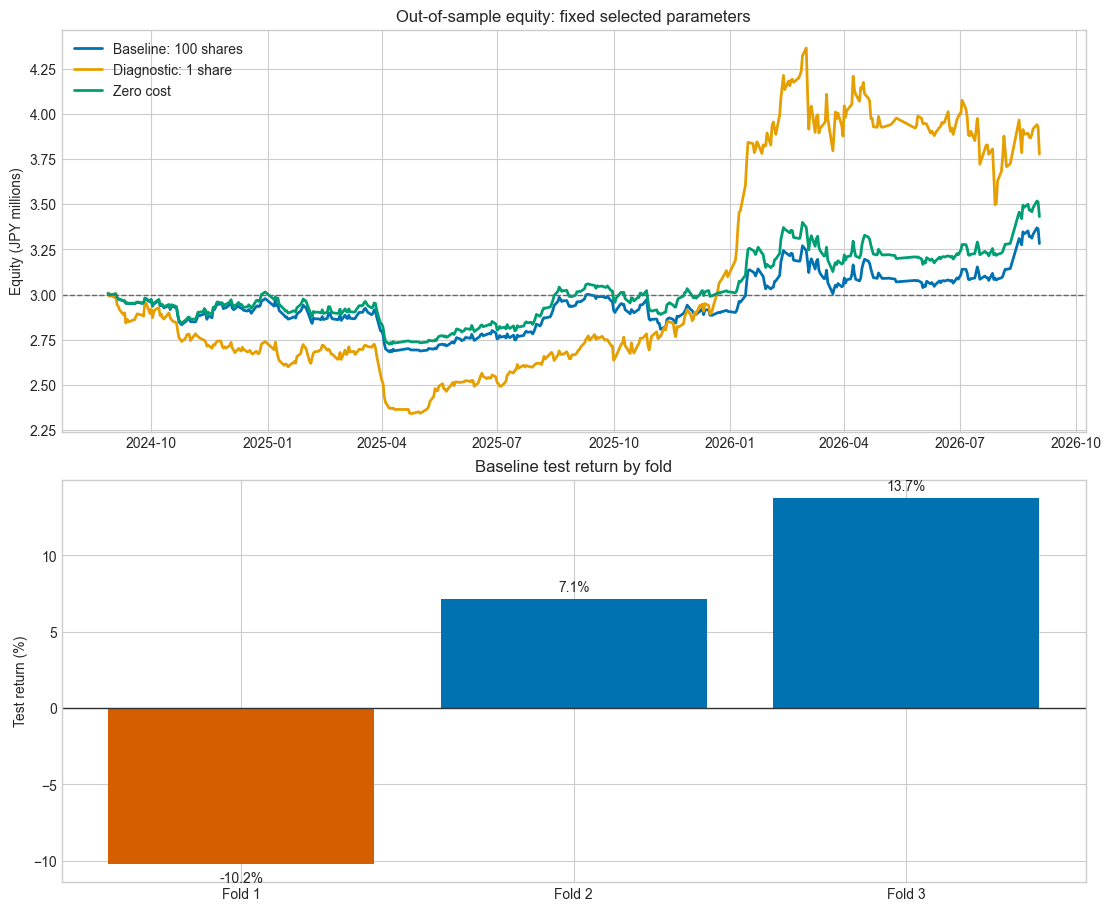

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), constrained_layout=True)

for label, frame, color in [
    ("Baseline: 100 shares", baseline_fixed_equity, COLORS["baseline"]),
    ("Diagnostic: 1 share", lot1_equity, COLORS["lot1"]),
    ("Zero cost", zero_cost_equity, COLORS["zero_cost"]),
]:
    axes[0].plot(frame["date"], frame["equity"] / 1_000_000, label=label, color=color, linewidth=2)
axes[0].axhline(3.0, color="#666666", linewidth=1, linestyle="--")
axes[0].set_title("Out-of-sample equity: fixed selected parameters")
axes[0].set_ylabel("Equity (JPY millions)")
axes[0].legend(frameon=False)

fold_labels = [f"Fold {fold}" for fold in fold_performance["fold"]]
x = np.arange(len(fold_labels))
axes[1].bar(
    x,
    fold_performance["test_total_return"] * 100,
    color=[COLORS["negative"] if value < 0 else COLORS["baseline"] for value in fold_performance["test_total_return"]],
)
axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].set_xticks(x, fold_labels)
axes[1].set_title("Baseline test return by fold")
axes[1].set_ylabel("Test return (%)")
for index, value in enumerate(fold_performance["test_total_return"] * 100):
    axes[1].text(index, value + (0.5 if value >= 0 else -1.2), f"{value:.1f}%", ha="center")

display(
    fig,
    metadata={
        "image/png": {
            "alt": (
                "Top: out-of-sample equity for the baseline, one-share diagnostic, "
                "and zero-cost scenarios. Bottom: baseline test return for each fold."
            )
        }
    },
)
plt.close(fig)

## Takeaways

In [10]:
baseline_cagr = float(baseline_fixed_summary["cagr"])
lot1_cagr = float(lot1_summary["cagr"])
zero_cost_cagr = float(zero_cost_summary["cagr"])
all_affordability = affordability.loc["all"]
worst_fold = fold_performance.loc[fold_performance["test_total_return"].idxmin()]
total_cost = float(cost_summary.iloc[0]["total_cost"])

display(
    Markdown(
        f"""
1. **目標未達は再現できた。** OOS CAGRは **{baseline_cagr:.2%}**、最大ドローダウンは
   **{baseline_fixed_summary['max_drawdown']:.2%}**。15%目標との差は **{TARGET_CAGR - baseline_cagr:.2%}ポイント**。
2. **最大のモデル内感度は資金配分と100株単元。** 同じfoldパラメータを固定した1株単位の診断では
   CAGRが **{lot1_cagr:.2%}** まで変化した。一方、候補機会の
   **{all_affordability['over_budget_share']:.1%}** は初期1枠150,000円で100株を買えず、
   baselineのfold別平均現金比率は **{exposure['average_cash_ratio'].min():.1%}〜{exposure['average_cash_ratio'].max():.1%}** だった。
   ただし1株単位は現行の実運用前提ではなく、収益改善の保証ではない。
3. **学習段階から15%を支持していない。** 選択候補の学習CAGRは3foldとも
   **{stability['selected_train_cagr'].max():.2%}以下**。学習順位とテスト順位の相関は
   **{stability['train_test_rank_correlation'].min():.2f}〜{stability['train_test_rank_correlation'].max():.2f}** と弱く、
   小さな4候補グリッドからの選択が安定した優位性を示していない。
4. **最初のOOS区間が全体を強く押し下げた。** Fold {int(worst_fold['fold'])} は
   **{worst_fold['test_total_return']:.2%}**。後半2foldのプラスだけでは回復し切れていない。
5. **取引コスト単独では説明できない。** 固定パラメータ・コストゼロでもCAGRは
   **{zero_cost_cagr:.2%}** に留まり、15%には遠い。独立fold会計上の手数料＋スリッページは
   **{total_cost:,.0f}円**。

**判定:** 15%目標を満たさない主因は、(a) 現在のシグナル候補群自体が学習期間で高CAGRを示していないこと、
(b) 300万円・20枠・100株単元の組合せによる投資余力の未使用、(c) fold間での選択順位の不安定さ。
手数料は副次要因。次工程では、まず `candidates[:slots]` の購入不能候補スキップ順を回帰テスト付きで是正し、
その後も100株単元を維持したまま資金配分とパラメータ安定性を再WFAするのが妥当。
"""
    )
)


1. **目標未達は再現できた。** OOS CAGRは **4.57%**、最大ドローダウンは
   **-10.71%**。15%目標との差は **10.43%ポイント**。
2. **最大のモデル内感度は資金配分と100株単元。** 同じfoldパラメータを固定した1株単位の診断では
   CAGRが **12.12%** まで変化した。一方、候補機会の
   **64.8%** は初期1枠150,000円で100株を買えず、
   baselineのfold別平均現金比率は **29.4%〜44.9%** だった。
   ただし1株単位は現行の実運用前提ではなく、収益改善の保証ではない。
3. **学習段階から15%を支持していない。** 選択候補の学習CAGRは3foldとも
   **1.05%以下**。学習順位とテスト順位の相関は
   **-0.40〜0.20** と弱く、
   小さな4候補グリッドからの選択が安定した優位性を示していない。
4. **最初のOOS区間が全体を強く押し下げた。** Fold 1 は
   **-10.20%**。後半2foldのプラスだけでは回復し切れていない。
5. **取引コスト単独では説明できない。** 固定パラメータ・コストゼロでもCAGRは
   **6.91%** に留まり、15%には遠い。独立fold会計上の手数料＋スリッページは
   **85,389円**。

**判定:** 15%目標を満たさない主因は、(a) 現在のシグナル候補群自体が学習期間で高CAGRを示していないこと、
(b) 300万円・20枠・100株単元の組合せによる投資余力の未使用、(c) fold間での選択順位の不安定さ。
手数料は副次要因。次工程では、まず `candidates[:slots]` の購入不能候補スキップ順を回帰テスト付きで是正し、
その後も100株単元を維持したまま資金配分とパラメータ安定性を再WFAするのが妥当。


### Caveats

- 現在の `fundamentals.scalecat` を過去にも適用しており、サバイバーシップ・バイアスが残る。
- 1株反実仮想は単元制約の感度を測る診断で、流動性・単元未満株サービス等をモデル化していない。
- 候補機会の購入可能率はポートフォリオ状態を除く前の母集団で、実注文拒否件数ではない。
- 対象期間は約2年のOOSで、相場局面への依存が大きい。統計的な将来保証には使えない。
- 本ノートブックは読み取り専用であり、売買判断や本番運用の変更を行わない。